In [5]:
import numpy as np
import pandas as pd

Wage = pd.read_csv("Wage.csv")
X = Wage[['age']]
y = Wage['wage']
Wage

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154
...,...,...,...,...,...,...,...,...,...,...,...
2995,2008,44,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,2. >=Very Good,1. Yes,5.041393,154.685293
2996,2007,30,2. Married,1. White,2. HS Grad,2. Middle Atlantic,1. Industrial,2. >=Very Good,2. No,4.602060,99.689464
2997,2005,27,2. Married,2. Black,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.193125,66.229408
2998,2005,27,1. Never Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,2. >=Very Good,1. Yes,4.477121,87.981033


In [6]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

degrees = range(1, 11)
cv_mse = []

for d in degrees:
    poly = PolynomialFeatures(d)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()
    neg_mse = cross_val_score(model, X_poly, y,
                              scoring='neg_mean_squared_error',
                              cv=10)
    cv_mse.append(-neg_mse.mean())

best_d = degrees[np.argmin(cv_mse)]
print("Best degree from CV:", best_d)


Best degree from CV: 4


In [7]:
import statsmodels.api as sm
from itertools import combinations

anova_pvalues = []

for d in degrees[:-1]:
    # smaller model
    poly1 = PolynomialFeatures(d).fit_transform(X)
    model1 = sm.OLS(y, poly1).fit()

    # larger model
    poly2 = PolynomialFeatures(d+1).fit_transform(X)
    model2 = sm.OLS(y, poly2).fit()

    # ANOVA test
    anova_res = sm.stats.anova_lm(model1, model2)
    pval = anova_res['Pr(>F)'][1]
    anova_pvalues.append(pval)

anova_df = pd.DataFrame({
    "degree d+1": range(2, 11),
    "ANOVA p-value": anova_pvalues
})

print("\nANOVA comparison (d vs d+1):")
print(anova_df)



ANOVA comparison (d vs d+1):
   degree d+1  ANOVA p-value
0           2   3.077420e-32
1           3   1.687063e-03
2           4   5.103865e-02
3           5   3.696820e-01
4           6   1.162015e-01
5           7            NaN
6           8            NaN
7           9            NaN
8          10            NaN


C:\Users\jack9\python\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


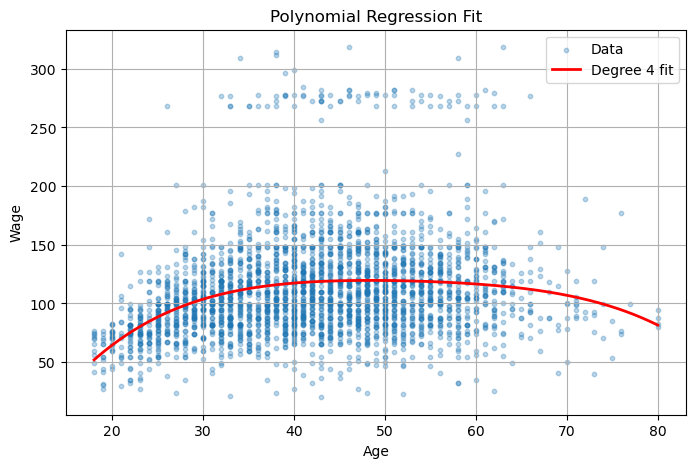

In [8]:
import matplotlib.pyplot as plt
# Fit the best model
poly_best = PolynomialFeatures(best_d)
X_poly_best = poly_best.fit_transform(X)

model_best = LinearRegression().fit(X_poly_best, y)

# Smooth curve
age_grid = np.linspace(X.min(), X.max(), 300).reshape(-1,1)
age_poly_grid = poly_best.transform(age_grid)
pred = model_best.predict(age_poly_grid)

# Plot
plt.figure(figsize=(8,5))
plt.scatter(X, y, s=10, alpha=0.3, label="Data")
plt.plot(age_grid, pred, color="red", linewidth=2, label=f"Degree {best_d} fit")
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title("Polynomial Regression Fit")
plt.legend()
plt.grid(True)
plt.show()


In [10]:
from sklearn.preprocessing import KBinsDiscretizer
k_values = range(2, 11)
cv_mse = []

for k in k_values:
    # step function transform
    binner = KBinsDiscretizer(n_bins=k, encode='onehot-dense', strategy='uniform')
    X_step = binner.fit_transform(X)

    model = LinearRegression()
    neg_mse = cross_val_score(model, X_step, y,
                              scoring='neg_mean_squared_error',
                              cv=10)
    cv_mse.append(-neg_mse.mean())

best_k = k_values[np.argmin(cv_mse)]
print("Best number of cuts (k):", best_k)


Best number of cuts (k): 8


C:\Users\jack9\python\Lib\site-packages\sklearn\preprocessing\_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(
C:\Users\jack9\python\Lib\site-packages\sklearn\preprocessing\_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(
C:\Users\jack9\python\Lib\site-packages\sklearn\preprocessing\_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(
C:\Users\jack9\python\Lib\site-packages\sklearn\preprocessing\_discretization.py:2

In [11]:
binner = KBinsDiscretizer(n_bins=best_k, encode='onehot-dense', strategy='uniform')
X_step_best = binner.fit_transform(X)

model = LinearRegression().fit(X_step_best, y)


C:\Users\jack9\python\Lib\site-packages\sklearn\preprocessing\_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


C:\Users\jack9\python\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KBinsDiscretizer was fitted with feature names
  warnings.warn(


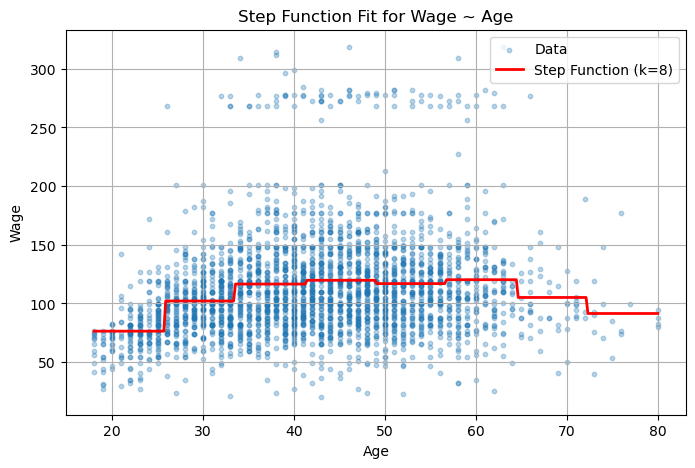

In [12]:
# Generate smooth age grid
age_grid = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
age_grid_step = binner.transform(age_grid)

pred = model.predict(age_grid_step)

plt.figure(figsize=(8,5))
plt.scatter(X, y, s=10, alpha=0.3, label="Data")
plt.plot(age_grid, pred, color='red', linewidth=2, label=f"Step Function (k={best_k})")
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title("Step Function Fit for Wage ~ Age")
plt.legend()
plt.grid(True)
plt.show()
